# 📏 Numerical Integration (Quadrature) — Numerical Analysis I
**Reference:** Burden & Faires, *Numerical Analysis*, 9th ed. — Chapter 4, Sections 4.3–4.6

---
## 📚 Topics Covered

| # | Method | Error Order | Notes |
|---|--------|------------|-------|
| 1 | Trapezoidal Rule | $O(h^2)$ | DOP = 1 |
| 2 | Simpson's 1/3 Rule | $O(h^4)$ | DOP = 3 |
| 3 | Simpson's 3/8 Rule | $O(h^4)$ | 4 points |
| 4 | Composite Rules | $O(h^2)$/$O(h^4)$ | n subintervals |
| 5 | Romberg Integration | $O(h^{2k})$ | Richardson extrapolation |
| 6 | Gaussian Quadrature | $O(h^{2n})$ | Optimal nodes & weights |
| 7 | Adaptive Quadrature | Adaptive | Error-controlled |

> **Goal:** Approximate $\displaystyle I = \int_a^b f(x)\, dx$ accurately and efficiently.

In [1]:
# ─────────────────────────────────────────────
# 📦 Imports & Setup
# ─────────────────────────────────────────────
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 12})
print('✅ Setup complete.')

✅ Setup complete.


---
## 1️⃣ Newton-Cotes Formulas

**Trapezoidal Rule** (2 points, DOP = 1):
$$\int_a^b f(x)\,dx \approx \frac{h}{2}[f(a) + f(b)], \quad E_T = -\frac{h^3}{12}f''(\xi)$$

**Simpson's 1/3 Rule** (3 points, DOP = 3):
$$\int_a^b f(x)\,dx \approx \frac{h}{3}[f(a) + 4f(m) + f(b)], \quad E_S = -\frac{h^5}{90}f^{(4)}(\xi)$$

**Simpson's 3/8 Rule** (4 points, DOP = 3):
$$\int_a^b f(x)\,dx \approx \frac{3h}{8}[f(x_0) + 3f(x_1) + 3f(x_2) + f(x_3)]$$

In [2]:
# ─── Simple (single-panel) quadrature rules ───

def trapezoidal(f, a, b):
    """Simple Trapezoidal Rule — O(h²) — DOP = 1"""
    h = b - a
    return (h / 2) * (f(a) + f(b))

def simpsons_13(f, a, b):
    """Simpson's 1/3 Rule — O(h⁴) — DOP = 3.  Requires even n."""
    m = (a + b) / 2
    h = (b - a) / 2
    return (h / 3) * (f(a) + 4*f(m) + f(b))

def simpsons_38(f, a, b):
    """Simpson's 3/8 Rule — O(h⁴) — DOP = 3.  Uses 4 equally-spaced points."""
    h = (b - a) / 3
    x1 = a + h
    x2 = a + 2*h
    return (3*h / 8) * (f(a) + 3*f(x1) + 3*f(x2) + f(b))


# ── Test: ∫₀¹ xeˣ dx = 1.0  (exact) ──
f_test  = lambda x: x * np.exp(x)
true_I  = 1.0   # exact: integration by parts gives [xeˣ - eˣ]₀¹ = 1

a, b = 0, 1
print("📌 f(x) = xeˣ  on [0,1],  True ∫ = 1.000000")
print(f"   Trapezoidal   ≈ {trapezoidal(f_test, a, b):.8f}  |error| = {abs(trapezoidal(f_test,a,b)-true_I):.2e}")
print(f"   Simpson's 1/3 ≈ {simpsons_13(f_test, a, b):.8f}  |error| = {abs(simpsons_13(f_test,a,b)-true_I):.2e}")
print(f"   Simpson's 3/8 ≈ {simpsons_38(f_test, a, b):.8f}  |error| = {abs(simpsons_38(f_test,a,b)-true_I):.2e}")

📌 f(x) = xeˣ  on [0,1],  True ∫ = 1.000000
   Trapezoidal   ≈ 1.35914091  |error| = 3.59e-01
   Simpson's 1/3 ≈ 1.00262073  |error| = 2.62e-03
   Simpson's 3/8 ≈ 1.00117029  |error| = 1.17e-03


---
## 2️⃣ Composite Rules

Apply the basic rule on each of $n$ subintervals for higher accuracy.

**Composite Trapezoidal:**
$$T_n = \frac{h}{2}\left[f(a) + 2\sum_{j=1}^{n-1}f(x_j) + f(b)\right], \quad E_T = -\frac{b-a}{12}h^2 f''(\mu)$$

**Composite Simpson's:**
$$S_n = \frac{h}{3}\left[f(a) + 2\sum_{j=1}^{n/2-1}f(x_{2j}) + 4\sum_{j=1}^{n/2}f(x_{2j-1}) + f(b)\right], \quad E_S = -\frac{b-a}{180}h^4 f^{(4)}(\mu)$$

In [3]:
def composite_trapezoidal(f, a, b, n):
    """
    Composite Trapezoidal Rule.

    Parameters: f — function, a,b — limits, n — number of subintervals
    Returns: float — integral approximation
    """
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)   # n+1 equally-spaced nodes
    y = f(x)
    return (h / 2) * (y[0] + 2*np.sum(y[1:-1]) + y[-1])


def composite_simpsons(f, a, b, n):
    """
    Composite Simpson's 1/3 Rule.

    Parameters: f — function, a,b — limits, n — EVEN number of subintervals
    Returns: float — integral approximation
    """
    if n % 2 != 0:
        raise ValueError("n must be even for Composite Simpson's Rule.")
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    # Weights: 1, 4, 2, 4, 2, ..., 4, 1
    return (h / 3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])


# ── Accuracy comparison for ∫₀¹ xeˣ dx ──
n_vals = [2, 4, 8, 16, 32, 64]
rows = []
for n in n_vals:
    T = composite_trapezoidal(f_test, 0, 1, n)
    S = composite_simpsons(f_test, 0, 1, n)
    rows.append([n, T, abs(T-true_I), S, abs(S-true_I)])

df_c = pd.DataFrame(rows, columns=['n', 'Trapezoidal Tₙ', '|Error T|', "Simpson's Sₙ", '|Error S|'])
print("\n📊 Composite Rules — ∫₀¹ xeˣ dx = 1")
print(df_c.to_string(index=False, float_format='{:.8f}'.format))


📊 Composite Rules — ∫₀¹ xeˣ dx = 1
 n  Trapezoidal Tₙ  |Error T|  Simpson's Sₙ  |Error S|
 2      1.09175077 0.09175077    1.00262073 0.00262073
 4      1.02306448 0.02306448    1.00016905 0.00016905
 8      1.00577411 0.00577411    1.00001065 0.00001065
16      1.00144403 0.00144403    1.00000067 0.00000067
32      1.00036104 0.00036104    1.00000004 0.00000004
64      1.00009026 0.00009026    1.00000000 0.00000000


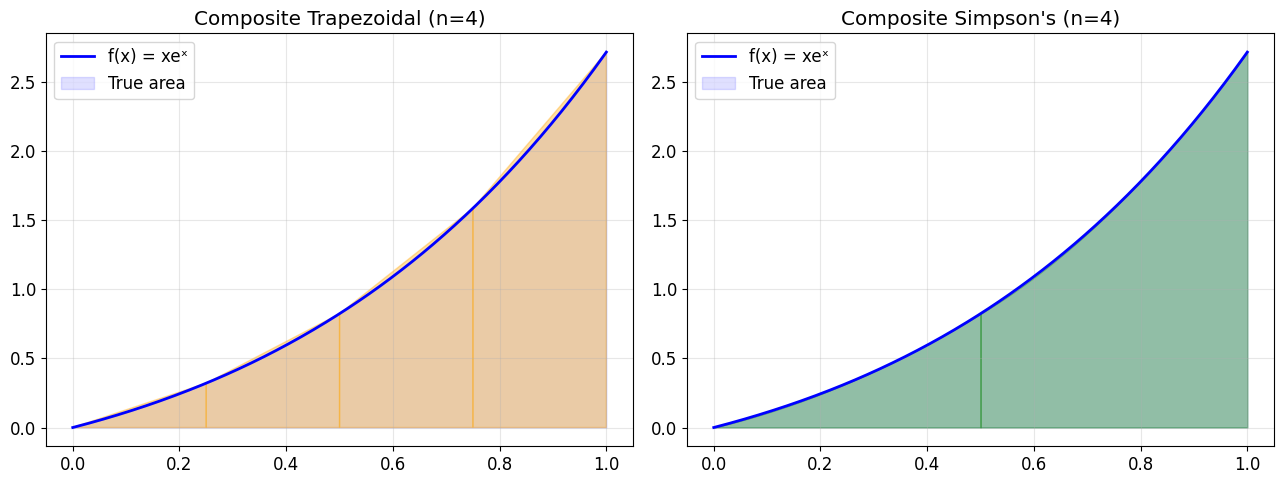

In [4]:
# ── Visualize geometric interpretation ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x_plot = np.linspace(0, 1, 300)
n_demo = 4
x_nodes = np.linspace(0, 1, n_demo + 1)
h = 1 / n_demo

for ax, title in zip([ax1, ax2], ['Composite Trapezoidal (n=4)', "Composite Simpson's (n=4)"]):
    ax.plot(x_plot, f_test(x_plot), 'b-', linewidth=2, label='f(x) = xeˣ')
    ax.fill_between(x_plot, f_test(x_plot), alpha=0.12, color='blue', label='True area')

# Trapezoidal shading
for i in range(n_demo):
    xs = [x_nodes[i], x_nodes[i], x_nodes[i+1], x_nodes[i+1]]
    ys = [0, f_test(x_nodes[i]), f_test(x_nodes[i+1]), 0]
    ax1.fill(xs, ys, alpha=0.35, color='orange')
ax1.set_title('Composite Trapezoidal (n=4)'); ax1.legend()

# Simpson's shading (parabolic arcs)
for i in range(0, n_demo, 2):
    xi = np.linspace(x_nodes[i], x_nodes[i+2], 100)
    # Quadratic interpolant through 3 points
    coeffs = np.polyfit([x_nodes[i], x_nodes[i+1], x_nodes[i+2]],
                        [f_test(x_nodes[j]) for j in [i, i+1, i+2]], 2)
    yi = np.polyval(coeffs, xi)
    ax2.fill_between(xi, yi, alpha=0.35, color='green')
ax2.set_title("Composite Simpson's (n=4)"); ax2.legend()

plt.tight_layout()
plt.show()

---
## 3️⃣ Romberg Integration

**Idea:** Systematically apply Richardson's Extrapolation to the Composite Trapezoidal results, each step doubling the accuracy order.

$$R_{k,1} = T_{2^{k-1}} \quad (\text{Trapezoidal with } 2^{k-1} \text{ subintervals})$$
$$R_{i,j} = \frac{4^{j-1}R_{i,j-1} - R_{i-1,j-1}}{4^{j-1}-1}$$

$R_{i,j}$ has accuracy order $O(h^{2j})$.

In [5]:
def romberg_integration(f, a, b, max_level=6):
    """
    Romberg Integration.

    Parameters:
    -----------
    f         : callable — integrand
    a, b      : float    — integration limits
    max_level : int      — number of rows in Romberg table

    Returns:
    --------
    R         : 2D numpy array — full Romberg table
    best      : float          — most accurate estimate R[max_level-1, max_level-1]
    """
    R = np.zeros((max_level, max_level))

    # Fill first column: Composite Trapezoidal with 2^(k-1) subintervals
    for k in range(max_level):
        n = 2**k
        R[k, 0] = composite_trapezoidal(f, a, b, n)

    # Extrapolation: fill remaining columns
    for j in range(1, max_level):
        for i in range(j, max_level):
            R[i, j] = (4**j * R[i, j-1] - R[i-1, j-1]) / (4**j - 1)

    return R, R[max_level-1, max_level-1]


# ── Example: ∫₀¹ 1/(1+x²) dx = π/4 ──
g  = lambda x: 1 / (1 + x**2)
true_pi4 = np.pi / 4

R, best = romberg_integration(g, 0, 1, max_level=6)

print(f"\n📌 Romberg Table — ∫₀¹ 1/(1+x²) dx = π/4 ≈ {true_pi4:.15f}")
print(f"   Best Romberg estimate = {best:.15f}")
print(f"   Absolute error        = {abs(best - true_pi4):.4e}\n")

# Display table
cols = [f'O(h^{2*(j+1)})' for j in range(R.shape[1])]
rows_idx = [f'k={k} (n={2**k})' for k in range(R.shape[0])]
df_R = pd.DataFrame(R, index=rows_idx, columns=cols)
# Replace zeros with NaN for cleaner display
df_R = df_R.replace(0.0, np.nan)
print(df_R.to_string(float_format='{:.12f}'.format))


📌 Romberg Table — ∫₀¹ 1/(1+x²) dx = π/4 ≈ 0.785398163397448
   Best Romberg estimate = 0.785398163409561
   Absolute error        = 1.2113e-11

                   O(h^2)         O(h^4)         O(h^6)         O(h^8)        O(h^10)        O(h^12)
k=0 (n=1)  0.750000000000            NaN            NaN            NaN            NaN            NaN
k=1 (n=2)  0.775000000000 0.783333333333            NaN            NaN            NaN            NaN
k=2 (n=4)  0.782794117647 0.785392156863 0.785529411765            NaN            NaN            NaN
k=3 (n=8)  0.784747123623 0.785398125615 0.785398523531 0.785396445940            NaN            NaN
k=4 (n=16) 0.785235403010 0.785398162806 0.785398165286 0.785398159599 0.785398166319            NaN
k=5 (n=32) 0.785357473294 0.785398163388 0.785398163427 0.785398163398 0.785398163412 0.785398163410


---
## 4️⃣ Gaussian Quadrature

**Principle:** Choose both nodes AND weights optimally to maximize DOP.

An $n$-point Gaussian rule achieves **DOP = $2n-1$** — far better than Newton-Cotes!

The nodes are roots of the **Legendre polynomial** $P_n(x)$ on $[-1, 1]$.

**Interval transformation** to use on $[a, b]$:
$$x = \frac{b-a}{2}\xi + \frac{a+b}{2}, \quad dx = \frac{b-a}{2}\,d\xi$$
$$\int_a^b f(x)\,dx = \frac{b-a}{2}\int_{-1}^{1} f\!\left(\frac{b-a}{2}\xi + \frac{a+b}{2}\right)d\xi$$

In [6]:
# ─── Hard-coded Gauss-Legendre nodes & weights on [-1,1] ───
GAUSS_NODES_WEIGHTS = {
    1: ([0.0],
        [2.0]),
    2: ([-0.5773502691896257, 0.5773502691896257],
        [1.0, 1.0]),
    3: ([-0.7745966692414834, 0.0, 0.7745966692414834],
        [0.5555555555555556, 0.8888888888888888, 0.5555555555555556]),
    4: ([-0.8611363115940526, -0.3399810435848563,
          0.3399810435848563,  0.8611363115940526],
        [0.3478548451374538,  0.6521451548625461,
         0.6521451548625461,  0.3478548451374538]),
    5: ([-0.9061798459366350, -0.5384693101056831, 0.0,
          0.5384693101056831,  0.9061798459366350],
        [0.2369268850561891,  0.4786286704993665, 0.5688888888888889,
         0.4786286704993665,  0.2369268850561891]),
}

def gaussian_quadrature(f, a, b, n=5):
    """
    Gaussian (Gauss-Legendre) Quadrature.

    Parameters:
    -----------
    f    : callable — integrand
    a, b : float    — integration limits
    n    : int      — number of points (1 to 5)

    Returns:
    --------
    float — integral approximation
    """
    if n not in GAUSS_NODES_WEIGHTS:
        raise ValueError(f"n must be 1–5. Got {n}.")

    xi_list, w_list = GAUSS_NODES_WEIGHTS[n]

    # Linear transformation from [-1,1] to [a,b]
    mid   = (b + a) / 2
    half  = (b - a) / 2

    result = 0.0
    for xi, w in zip(xi_list, w_list):
        x = half * xi + mid    # transform node to [a, b]
        result += w * f(x)

    return half * result


# ── Comparison across n ──
g = lambda x: 1 / (1 + x**2)
true_I = np.pi / 4

print(f"\n📌 Gaussian Quadrature — ∫₀¹ 1/(1+x²) dx = π/4 ≈ {true_I:.15f}\n")
print(f"{'Points n':>10} {'DOP':>6} {'Approximation':>18} {'|Error|':>14}")
print("-" * 54)
for n in range(1, 6):
    approx = gaussian_quadrature(g, 0, 1, n)
    err = abs(approx - true_I)
    print(f"{n:>10} {2*n-1:>6} {approx:>18.15f} {err:>14.4e}")


📌 Gaussian Quadrature — ∫₀¹ 1/(1+x²) dx = π/4 ≈ 0.785398163397448

  Points n    DOP      Approximation        |Error|
------------------------------------------------------
         1      1  0.800000000000000     1.4602e-02
         2      3  0.786885245901639     1.4871e-03
         3      5  0.785267034990792     1.3113e-04
         4      7  0.785402976311451     4.8129e-06
         5      9  0.785398159971240     3.4262e-09


---
## 5️⃣ Adaptive Quadrature

**Idea:** Concentrate effort where the function is least smooth — use large $h$ where $f$ is smooth and small $h$ where it oscillates or peaks.

**The 1/15 test:** Accept if:
$$|S(h/2) - S(h)| < 15 \cdot \text{TOL}_{\text{local}}$$
Otherwise subdivide the interval.

In [7]:
def adaptive_simpson(f, a, b, tol, depth=0, max_depth=50):
    """
    Adaptive Quadrature using Simpson's Rule with the 1/15 error test.

    Parameters:
    -----------
    f         : callable — integrand
    a, b      : float    — integration limits
    tol       : float    — error tolerance
    depth     : int      — current recursion depth (internal)
    max_depth : int      — maximum recursion depth

    Returns:
    --------
    float — integral approximation
    """
    m = (a + b) / 2

    # Full interval Simpson's approximation
    S_full = simpsons_13(f, a, b)

    # Two half-interval Simpson's approximations
    S_left  = simpsons_13(f, a, m)
    S_right = simpsons_13(f, m, b)
    S_half  = S_left + S_right

    # 1/15 error estimate
    error_est = abs(S_half - S_full) / 15

    if depth >= max_depth or error_est < tol:
        # Accept: return S_half + Richardson correction
        return S_half + (S_half - S_full) / 15
    else:
        # Subdivide and recurse
        left  = adaptive_simpson(f, a, m, tol/2, depth+1, max_depth)
        right = adaptive_simpson(f, m, b, tol/2, depth+1, max_depth)
        return left + right


# ── Example with a challenging integrand ──
# f(x) = sin(1/x) near x=0 — rapidly oscillating
f_hard = lambda x: np.sin(1/x) if x != 0 else 0

# Safer test: f(x) = 1/(1 + 25x²) — Runge's function
f_runge = lambda x: 1 / (1 + 25*x**2)
true_runge = np.arctan(5) * 2 / 5   # ∫₋₁¹ 1/(1+25x²) dx

result_adaptive = adaptive_simpson(f_runge, -1, 1, tol=1e-8)
result_scipy, _ = integrate.quad(f_runge, -1, 1)

print(f"\n📌 Adaptive Quadrature — ∫₋₁¹ 1/(1+25x²) dx")
print(f"   True value              = {true_runge:.15f}")
print(f"   Adaptive Simpson        = {result_adaptive:.15f}  |err| = {abs(result_adaptive - true_runge):.2e}")
print(f"   scipy.integrate.quad    = {result_scipy:.15f}  |err| = {abs(result_scipy - true_runge):.2e}")


📌 Adaptive Quadrature — ∫₋₁¹ 1/(1+25x²) dx
   True value              = 0.549360306778006
   Adaptive Simpson        = 0.549360306767856  |err| = 1.02e-11
   scipy.integrate.quad    = 0.549360306778007  |err| = 2.22e-16


---
## 6️⃣ Global Accuracy Comparison

Compare all methods on $\displaystyle\int_0^1 \frac{1}{1+x^2}\,dx = \frac{\pi}{4}$

In [8]:
g       = lambda x: 1 / (1 + x**2)
TRUE_I  = np.pi / 4
a, b    = 0, 1

results = {
    'Trapezoidal (n=8)':    composite_trapezoidal(g, a, b, 8),
    "Simpson's 1/3 (n=8)":  composite_simpsons(g, a, b, 8),
    'Romberg (6 levels)':   romberg_integration(g, a, b, 6)[1],
    'Gauss-Legendre (n=5)': gaussian_quadrature(g, a, b, 5),
    'Adaptive Simpson':     adaptive_simpson(g, a, b, tol=1e-10),
    'scipy.quad (reference)': integrate.quad(g, a, b)[0],
}

print(f"\n📊 Method Comparison — ∫₀¹ 1/(1+x²) dx = π/4 = {TRUE_I:.15f}\n")
print(f"{'Method':<30} {'Approximation':>18} {'Abs Error':>14}")
print("-" * 65)
for name, val in results.items():
    print(f"{name:<30} {val:>18.15f} {abs(val - TRUE_I):>14.4e}")


📊 Method Comparison — ∫₀¹ 1/(1+x²) dx = π/4 = 0.785398163397448

Method                              Approximation      Abs Error
-----------------------------------------------------------------
Trapezoidal (n=8)               0.784747123622772     6.5104e-04
Simpson's 1/3 (n=8)             0.785398125614677     3.7783e-08
Romberg (6 levels)              0.785398163409561     1.2113e-11
Gauss-Legendre (n=5)            0.785398159971240     3.4262e-09
Adaptive Simpson                0.785398163397465     1.6875e-14
scipy.quad (reference)          0.785398163397448     1.1102e-16


---
## 🧪 Practice Problems

1. Approximate $\int_0^2 \sin(\pi x)\,dx$ using:
   - Composite Trapezoidal with $n = 8$
   - Composite Simpson's with $n = 8$
   - Compute the rigorous error bound using $M_2 = \pi^2$ and $M_4 = \pi^4$

2. Build the full Romberg table for $\int_0^{\pi/4} \tan(x)\,dx$ up to $R_{4,4}$.

3. Use 3-point Gaussian quadrature to evaluate $\int_1^5 e^{-x^2}\,dx$.

4. Use Adaptive Quadrature to integrate $f(x) = \sqrt{x}\ln(x)$ on $[0.01, 2]$ with tolerance $10^{-6}$.

5. **Challenge:** Implement the double integral $\iint_R f(x,y)\,dA$ for $R = [0,1]\times[0,1]$, $f = e^{x+y}$.